In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# ML Algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Model Evaluation
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
import pandas as pd

column_names = [
    "Gender", "Age", "Debt", "Married", "BankCustomer",
    "Industry", "Ethnicity", "YearsEmployed",
    "PriorDefault", "Employed", "CreditScore",
    "DriversLicense", "Citizen", "ZipCode",
    "Income", "Approved"
]

# Load the original dataset
df = pd.read_csv("crx.csv", header=None, names=column_names)

# Display first 5 rows
df.head()

# Check dataset size
df.shape

# Get dataset information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Gender          690 non-null    str    
 1   Age             690 non-null    str    
 2   Debt            690 non-null    float64
 3   Married         690 non-null    str    
 4   BankCustomer    690 non-null    str    
 5   Industry        690 non-null    str    
 6   Ethnicity       690 non-null    str    
 7   YearsEmployed   690 non-null    float64
 8   PriorDefault    690 non-null    str    
 9   Employed        690 non-null    str    
 10  CreditScore     690 non-null    int64  
 11  DriversLicense  690 non-null    str    
 12  Citizen         690 non-null    str    
 13  ZipCode         690 non-null    str    
 14  Income          690 non-null    int64  
 15  Approved        690 non-null    str    
dtypes: float64(2), int64(2), str(12)
memory usage: 86.4 KB


In [3]:
df.columns

Index(['Gender', 'Age', 'Debt', 'Married', 'BankCustomer', 'Industry',
       'Ethnicity', 'YearsEmployed', 'PriorDefault', 'Employed', 'CreditScore',
       'DriversLicense', 'Citizen', 'ZipCode', 'Income', 'Approved'],
      dtype='str')

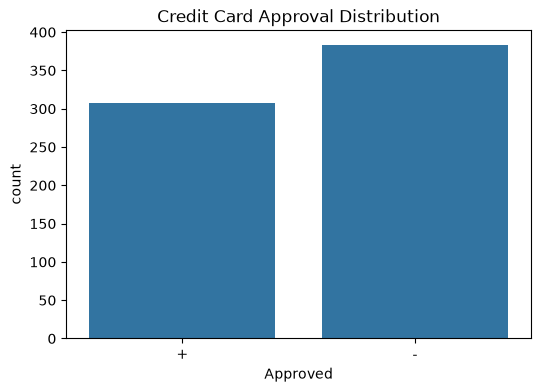

In [4]:
df['Approved'].value_counts()
plt.figure(figsize=(6,4))
sns.countplot(x='Approved', data=df)
plt.title("Credit Card Approval Distribution")
plt.show()

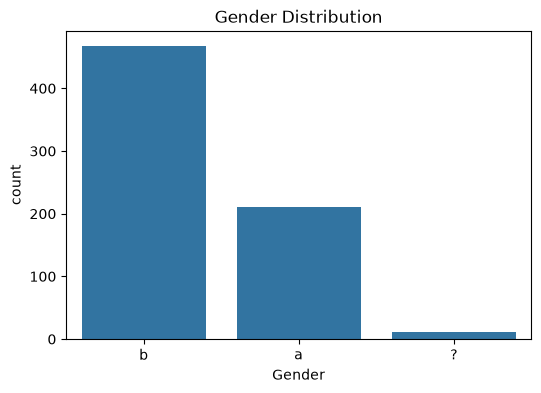

In [5]:
df['Gender'].value_counts()
plt.figure(figsize=(6,4))
sns.countplot(x='Gender', data=df)
plt.title("Gender Distribution")
plt.show()

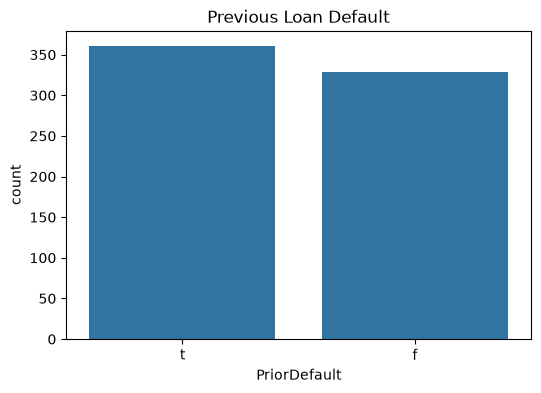

In [6]:
df['PriorDefault'].value_counts()
plt.figure(figsize=(6,4))
sns.countplot(x='PriorDefault', data=df)
plt.title("Previous Loan Default")
plt.show()

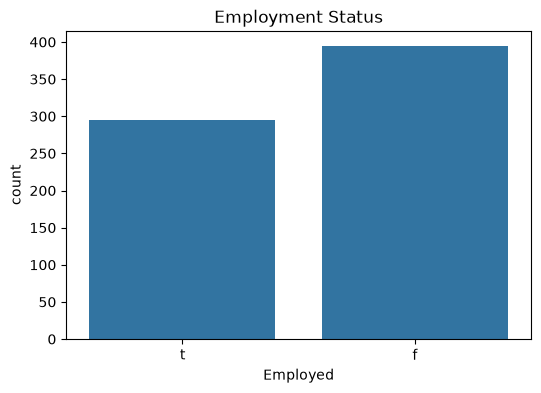

In [7]:
df['Employed'].value_counts()
plt.figure(figsize=(6,4))
sns.countplot(x='Employed', data=df)
plt.title("Employment Status")
plt.show()

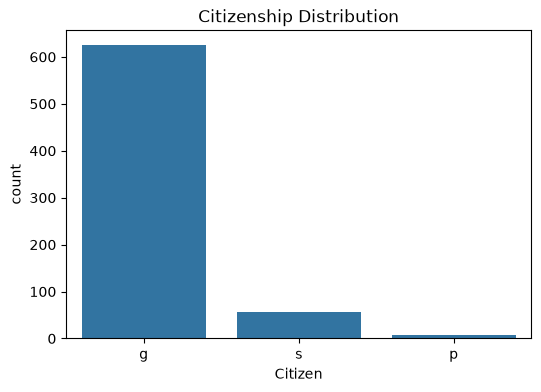

In [8]:
df['Citizen'].value_counts()
plt.figure(figsize=(6,4))
sns.countplot(x='Citizen', data=df)
plt.title("Citizenship Distribution")
plt.show()

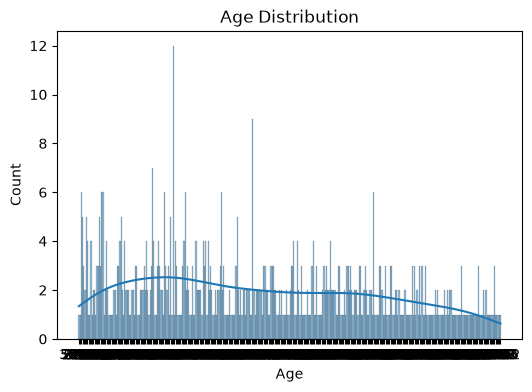

In [9]:
plt.figure(figsize=(6,4))
sns.histplot(df['Age'], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()

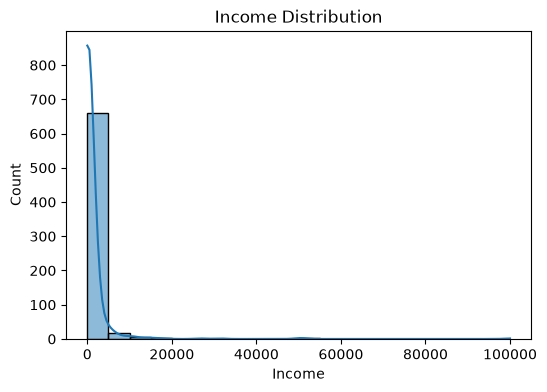

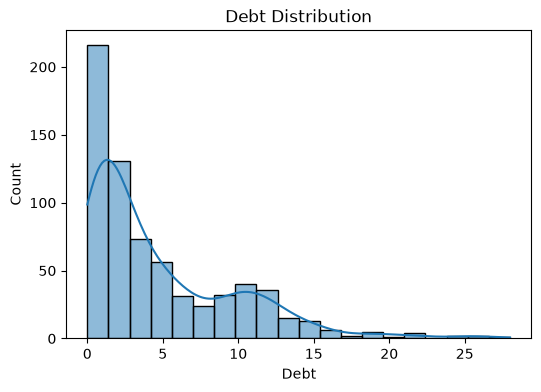

In [10]:
plt.figure(figsize=(6,4))
sns.histplot(df['Income'], bins=20, kde=True)
plt.title("Income Distribution")
plt.show()
plt.figure(figsize=(6,4))
sns.histplot(df['Debt'], bins=20, kde=True)
plt.title("Debt Distribution")
plt.show()

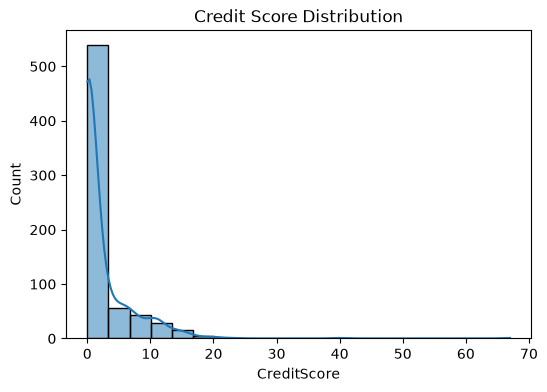

In [11]:
plt.figure(figsize=(6,4))
sns.histplot(df['CreditScore'], bins=20, kde=True)
plt.title("Credit Score Distribution")
plt.show()

In [12]:
# Select only numerical columns
numerical_data = df.select_dtypes(include=['int64', 'float64'])
numerical_data = df.drop(columns=['ZipCode']).select_dtypes(include=['int64', 'float64'])

# Calculate correlation
correlation = numerical_data.corr()

correlation

,Debt,YearsEmployed,CreditScore,Income
Debt,1.000000,0.298902,0.271207,0.123121
YearsEmployed,0.298902,1.000000,0.322330,0.051345
CreditScore,0.271207,0.322330,1.000000,0.063692
Income,0.123121,0.051345,0.063692,1.000000


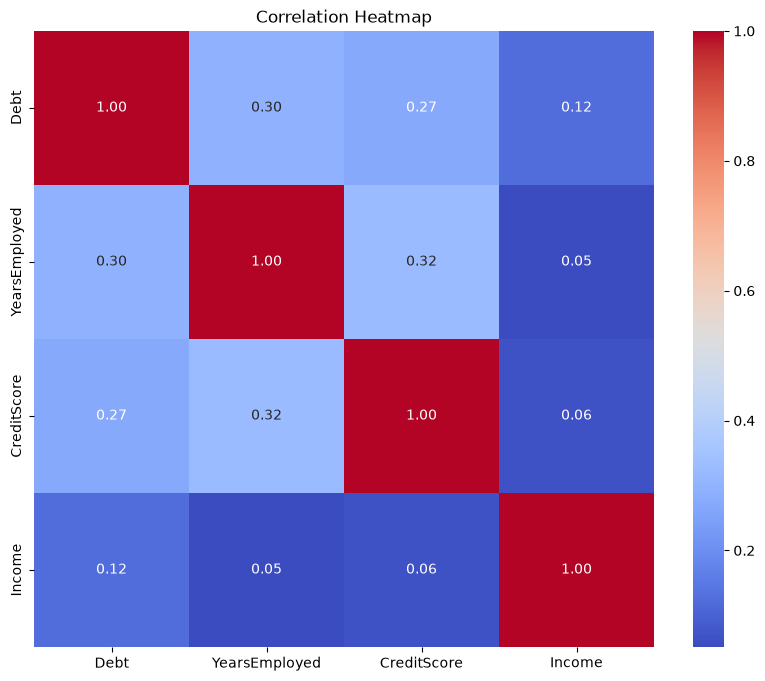

In [13]:
plt.figure(figsize=(10,8))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

In [14]:
df.describe()

,Debt,YearsEmployed,CreditScore,Income
count,690.000000,690.000000,690.00000,690.000000
mean,4.758725,2.223406,2.40000,1017.385507
std,4.978163,3.346513,4.86294,5210.102598
min,0.000000,0.000000,0.00000,0.000000
25%,1.000000,0.165000,0.00000,0.000000
50%,2.750000,1.000000,0.00000,5.000000
75%,7.207500,2.625000,3.00000,395.500000
max,28.000000,28.500000,67.00000,100000.000000


In [15]:
# Check duplicate rows
print("Duplicate rows:", df.duplicated().sum())

# Remove duplicate rows
df.drop_duplicates(inplace=True)

# Verify duplicates are removed
print("Duplicate rows after removal:", df.duplicated().sum())

# Check dataset size
print(df.shape)

Duplicate rows: 0
Duplicate rows after removal: 0
(690, 16)


In [16]:
# Count missing values
print(df.isnull().sum())

# Percentage of missing values
print((df.isnull().mean()) * 100)

Gender            0
Age               0
Debt              0
Married           0
BankCustomer      0
Industry          0
Ethnicity         0
YearsEmployed     0
PriorDefault      0
Employed          0
CreditScore       0
DriversLicense    0
Citizen           0
ZipCode           0
Income            0
Approved          0
dtype: int64
Gender            0.0
Age               0.0
Debt              0.0
Married           0.0
BankCustomer      0.0
Industry          0.0
Ethnicity         0.0
YearsEmployed     0.0
PriorDefault      0.0
Employed          0.0
CreditScore       0.0
DriversLicense    0.0
Citizen           0.0
ZipCode           0.0
Income            0.0
Approved          0.0
dtype: float64


In [17]:
import numpy as np

# Convert '?' to NaN if present
df.replace("?", np.nan, inplace=True)

# Check missing values
print(df.isnull().sum())

# Fill missing numeric values with median
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

# Fill missing categorical values with mode
categorical_cols = df.select_dtypes(include="object").columns
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Verify there are no missing values
print(df.isnull().sum())

Gender            12
Age               12
Debt               0
Married            6
BankCustomer       6
Industry           9
Ethnicity          9
YearsEmployed      0
PriorDefault       0
Employed           0
CreditScore        0
DriversLicense     0
Citizen            0
ZipCode           13
Income             0
Approved           0
dtype: int64
Gender            0
Age               0
Debt              0
Married           0
BankCustomer      0
Industry          0
Ethnicity         0
YearsEmployed     0
PriorDefault      0
Employed          0
CreditScore       0
DriversLicense    0
Citizen           0
ZipCode           0
Income            0
Approved          0
dtype: int64


In [18]:
from sklearn.preprocessing import LabelEncoder
import joblib

encoders = {}

# These are the categorical columns (excluding the target)
categorical_columns = [
    "Gender",
    "Married",
    "BankCustomer",
    "Industry",
    "Ethnicity",
    "PriorDefault",
    "Employed",
    "DriversLicense",
    "Citizen"
]

for col in categorical_columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

# Encode target separately
target_encoder = LabelEncoder()

joblib.dump(encoders, "encoders.pkl")

print(encoders.keys())

dict_keys(['Gender', 'Married', 'BankCustomer', 'Industry', 'Ethnicity', 'PriorDefault', 'Employed', 'DriversLicense', 'Citizen'])


In [19]:
df["Age"] = pd.to_numeric(df["Age"], errors="coerce")
df["ZipCode"] = pd.to_numeric(df["ZipCode"], errors="coerce")

In [20]:
print(df.dtypes)

Gender              int64
Age               float64
Debt              float64
Married             int64
BankCustomer        int64
Industry            int64
Ethnicity           int64
YearsEmployed     float64
PriorDefault        int64
Employed            int64
CreditScore         int64
DriversLicense      int64
Citizen             int64
ZipCode             int64
Income              int64
Approved              str
dtype: object


In [21]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Convert '?' to NaN (if your dataset contains '?')
df.replace("?", np.nan, inplace=True)

# Remove rows with missing values
df.dropna(inplace=True)

# Split features and target
X = df.drop("Approved", axis=1)
y = df["Approved"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Train model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [22]:
y_pred = model.predict(X_test)

In [23]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8115942028985508


In [24]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[52  9]
 [17 60]]


In [25]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           +       0.75      0.85      0.80        61
           -       0.87      0.78      0.82        77

    accuracy                           0.81       138
   macro avg       0.81      0.82      0.81       138
weighted avg       0.82      0.81      0.81       138



In [26]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Create the model
rf_model = RandomForestClassifier(random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluate
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.8333333333333334

Confusion Matrix:
[[51 10]
 [13 64]]

Classification Report:
              precision    recall  f1-score   support

           +       0.80      0.84      0.82        61
           -       0.86      0.83      0.85        77

    accuracy                           0.83       138
   macro avg       0.83      0.83      0.83       138
weighted avg       0.83      0.83      0.83       138



In [27]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(confusion_matrix(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.7753623188405797
[[50 11]
 [20 57]]
              precision    recall  f1-score   support

           +       0.71      0.82      0.76        61
           -       0.84      0.74      0.79        77

    accuracy                           0.78       138
   macro avg       0.78      0.78      0.77       138
weighted avg       0.78      0.78      0.78       138



In [28]:
print("Logistic Regression:", accuracy_score(y_test, y_pred))
print("Decision Tree:", accuracy_score(y_test, y_pred_dt))
print("Random Forest:", accuracy_score(y_test, y_pred_rf))

Logistic Regression: 0.8115942028985508
Decision Tree: 0.7753623188405797
Random Forest: 0.8333333333333334


In [29]:
import joblib
import os

print("Current folder:", os.getcwd())

model = joblib.load("model.pkl")
print(type(model))
print(model.feature_names_in_)
joblib.dump(encoders, "encoders.pkl")

Current folder: c:\Users\Archana\Desktop\Smart bridge project\5. Project Development Phase
<class 'sklearn.linear_model._logistic.LogisticRegression'>
['Gender' 'Age' 'Debt' 'Married' 'BankCustomer' 'Industry' 'Ethnicity'
 'YearsEmployed' 'PriorDefault' 'Employed' 'CreditScore' 'DriversLicense'
 'Citizen' 'ZipCode' 'Income']


['encoders.pkl']

In [30]:
import pandas as pd
column_names = [
    "Gender", "Age", "Debt", "Married", "BankCustomer",
    "Industry", "Ethnicity", "YearsEmployed",
    "PriorDefault", "Employed", "CreditScore",
    "DriversLicense", "Citizen", "ZipCode",
    "Income", "Approved"
]

df = pd.read_csv("crx.csv", header=None, names=column_names)

In [31]:
print(df.head())
print(df.dtypes)

  Gender    Age   Debt Married BankCustomer Industry Ethnicity  YearsEmployed  \
0      b  30.83  0.000       u            g        w         v           1.25   
1      a  58.67  4.460       u            g        q         h           3.04   
2      a  24.50  0.500       u            g        q         h           1.50   
3      b  27.83  1.540       u            g        w         v           3.75   
4      b  20.17  5.625       u            g        w         v           1.71   

  PriorDefault Employed  CreditScore DriversLicense Citizen ZipCode  Income  \
0            t        t            1              f       g   00202       0   
1            t        t            6              f       g   00043     560   
2            t        f            0              f       g   00280     824   
3            t        t            5              t       g   00100       3   
4            t        f            0              f       s   00120       0   

  Approved  
0        +  
1        +  

In [32]:
import joblib

encoders = joblib.load("encoders.pkl")

for col, encoder in encoders.items():
    print(f"{col}: {list(encoder.classes_)}")

Gender: ['a', 'b']
Married: ['l', 'u', 'y']
BankCustomer: ['g', 'gg', 'p']
Industry: ['aa', 'c', 'cc', 'd', 'e', 'ff', 'i', 'j', 'k', 'm', 'q', 'r', 'w', 'x']
Ethnicity: ['bb', 'dd', 'ff', 'h', 'j', 'n', 'o', 'v', 'z']
PriorDefault: ['f', 't']
Employed: ['f', 't']
DriversLicense: ['f', 't']
Citizen: ['g', 'p', 's']
